In [ ]:
%load_ext autoreload
%autoreload 2


from acc_sync.util import trim_time, sig_filter, load_session_data


client_rh = load_session_data(
    pt="RF001",
    session="2025_09_27",
    role="client",
    hand="R",
)

client_lh = load_session_data(
    pt="RF001",
    session="2025_09_27",
    role="client",
    hand="L",
)


therapist_rh = load_session_data(
    pt="RF001",
    session="2025_09_27",
    role="therapist",
    hand="R",
)

therapist_lh = load_session_data(
    pt="RF001",
    session="2025_09_27",
    role="therapist",
    hand="L",
)

client_rh = sig_filter(trim_time(client_rh['magnitude'], '15:07:00', '15:34:00'))
client_lh = sig_filter(trim_time(client_lh['magnitude'], '15:07:00', '15:34:00'))

therapist_rh = sig_filter(trim_time(therapist_rh['magnitude'], '15:07:00', '15:34:00'))
therapist_lh = sig_filter(trim_time(therapist_lh['magnitude'], '15:07:00', '15:34:00'))



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


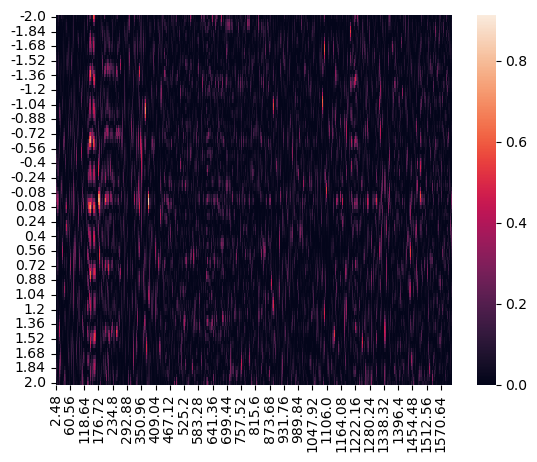

<Axes: >

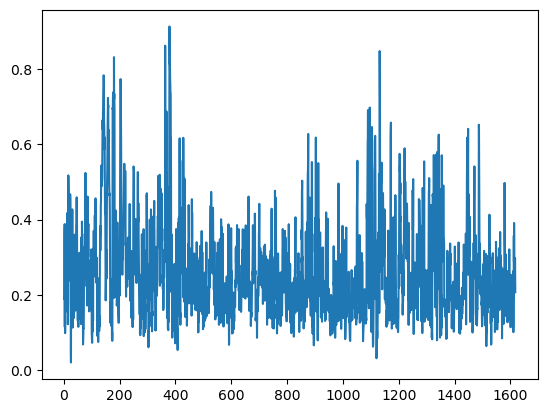

In [145]:
from acc_sync.util import frame_and_correlate
import matplotlib.pyplot as plt
import seaborn as sns


df = frame_and_correlate(therapist_rh, therapist_lh)
rsq = (df.T ** 2)
sns.heatmap(rsq)
plt.show()
rsq.max().plot()

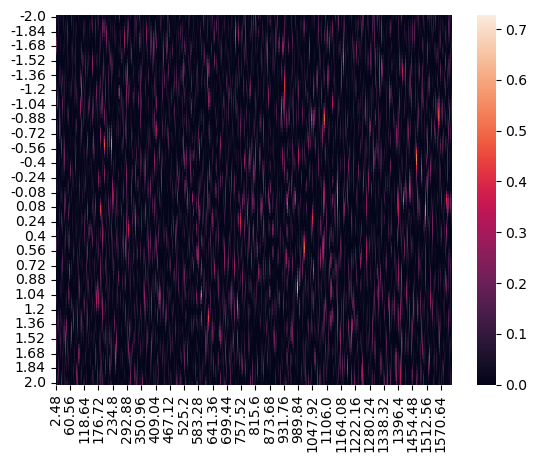

<Axes: >

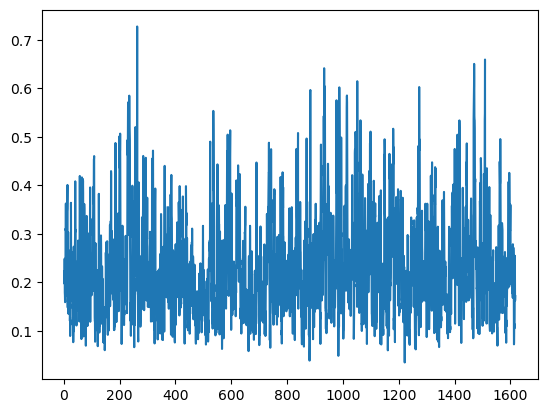

In [147]:
from acc_sync.util import frame_and_correlate
import matplotlib.pyplot as plt
import seaborn as sns


df = frame_and_correlate(client_lh, client_rh)
rsq = (df.T ** 2)
sns.heatmap(rsq)
plt.show()
rsq.max().plot()

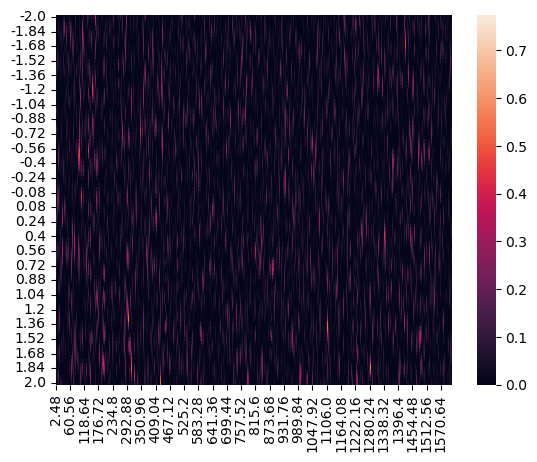

<Axes: >

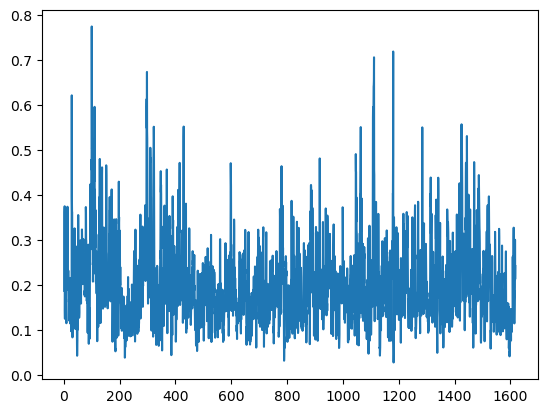

In [ ]:
from acc_sync.util import frame_xcorr
import matplotlib.pyplot as plt
import seaborn as sns


df = frame_xcorr(therapist_rh, client_rh)
rsq = (df.T ** 2)
sns.heatmap(rsq)
plt.show()
rsq.max().plot()

# 5/27 Meeting Agenda:
- [ ] Review input ingestion pipeline migration to python
- [ ] Discuss time lag cross-correlation analysis, caveats in AP's matlab implemention, and caveats in Yanke Sun's matlab implementation
    - https://github.com/khorinaj/SocSensor-Interpersonal-Synchrony-Analysis/blob/main/scr/xcrossSlidingWin.m
- [ ] Correlation was purly time-domain, discuss alternative frequency domain methods: cross wavelet transform, wavelet coherence from Sun and Ward's paper, and other related lits.
    - pywavelets, pycwt
- [ ] Present discussion with LLM and the unifiying two step framework for synchrony analysis.
- [ ] Present other miscellaneous ideas that might be of interest.
- [ ] Align thinking, goals and next steps.

## Input ingestion pipeline:

## Caveats in current xcorr implementation

## Frequency domain analysis

- Coherence is just like Correlation... it's just cross terms over self terms.

## Two step synchrony analysis framework

```
STAGE 1: Time-Frequency Representation          STAGE 2: Synchrony Metric
 ┌──────────────────────────────────────┐        ┌───────────────────────────┐
 │ • STFT (Linear grid)                 │        │ • Phase Locking Value     │
 │ • CQT  (Musical/Log grid)            │───────▶│   (Pure Phase Tracking)   │
 │ • CWT  (Continuous/Wavelet)          │        │ • Coherence               │
 │ • HHT  (Adaptive IMFs via EMD)       │        │   (Amplitude + Phase)     │
 └──────────────────────────────────────┘        └───────────────────────────┘
```

Multi-ratio Phase Locking Value? 1:2?

## Misc. ideas:
- Segmentation using x,y,z as a R^3 feature vector?
- Better visual representation and reading of the ACC data?
- Web interface for viewing and analyzing some data?

## Discussion and next steps:
- Repo outlook, forward collaboration expectations
- Identify the next concrete goal/step that's of highest value. 

# End of notebook